# Model Building & Creating Needed Functions:

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [11]:
# Define manual train-test split function
def train_test_split_custom(X, y, test_size=0.2, random_state=None):
    np.random.seed(random_state)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    split_point = int(X.shape[0] * (1 - test_size))
    X_train, X_test = X[indices[:split_point]], X[indices[split_point:]]
    y_train, y_test = y[indices[:split_point]], y[indices[split_point:]]
    return X_train, X_test, y_train, y_test

In [12]:
# Define standardize function
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_std = (X - mean) / std
    return X_std, mean, std

In [13]:
# Hinge loss function
def hinge_loss(w, b, X, y, reg=0.01):
    margins = 1 - y * (np.dot(X, w) + b)
    return np.mean(np.maximum(0, margins)) + reg * np.dot(w, w)


# Logistic loss function
def logistic_loss(w, b, X, y, reg=0.01):
    scores = y * (np.dot(X, w) + b)
    return np.mean(np.log(1 + np.exp(-scores))) + reg * np.dot(w, w)


# Logistic loss gradient
def logistic_gradient(w, b, X, y, reg=0.01):
    n_samples = X.shape[0]
    scores = y * (np.dot(X, w) + b)
    probs = 1 / (1 + np.exp(scores))  # sigmoid(-scores)
    dw = -np.dot((probs * y), X) / n_samples + 2 * reg * w
    db = -np.mean(probs * y)
    return dw, db

In [14]:
def train_svm(
    X, y, X_val, y_val, method="gradient", lr=0.01, epochs=1000, reg=0.01, tol=1e-4):
    """
    Train a linear SVM (hinge or logistic) with early stopping based on loss convergence.

    Parameters:
    - X, y: training data and labels
    - X_val, y_val: validation data and labels
    - method: 'gradient' (logistic gradient descent) or 'subgradient' (hinge subgradient descent)
    - lr: learning rate
    - epochs: maximum number of epochs
    - reg: L2 regularization strength
    - tol: tolerance threshold for early stopping (difference in training loss)

    Returns:
    - w, b: learned weights and bias
    - loss_hist, acc_hist: training loss and accuracy history
    - val_loss_hist, val_acc_hist: validation loss and accuracy history
    """
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0
    loss_hist, acc_hist = [], []
    val_loss_hist, val_acc_hist = [], []

    for epoch in range(epochs):
        # Compute gradient and losses
        if method == "gradient":
            dw, db = logistic_gradient(w, b, X, y, reg)
            train_loss = logistic_loss(w, b, X, y, reg)
            val_loss = logistic_loss(w, b, X_val, y_val, reg)
        elif method == "subgradient":
            margins = 1 - y * (X.dot(w) + b)
            mask = margins > 0
            #(max for the requlerization equation )
            grad_contrib = (-y[:, None] * X) * mask[:, None]
            #(result from differatiation of the  regulaization equation acording to W (weights))
            dw = np.mean(grad_contrib, axis=0) + 2 * reg * w
            #(result from differatiation of the  regulaization equation acording to b )
            db = np.mean(-y * mask)
            train_loss = hinge_loss(w, b, X, y, reg)
            val_loss = hinge_loss(w, b, X_val, y_val, reg)
        else:
            raise ValueError("Unknown method")

        # Update parameters
        w -= lr * dw
        b -= lr * db

        # Record metrics
        loss_hist.append(train_loss)
        acc = np.mean(np.sign(X.dot(w) + b) == y)
        acc_hist.append(acc)
        val_loss_hist.append(val_loss)
        val_acc = np.mean(np.sign(X_val.dot(w) + b) == y_val)
        val_acc_hist.append(val_acc)

        # Early stopping: check loss convergence
        if epoch > 0 and abs(val_loss_hist[-1] - val_loss_hist[-2]) <= tol:
            break

    return w, b, loss_hist, acc_hist, val_loss_hist, val_acc_hist

In [15]:
def plot_confusion(y_true, y_pred, title, fig_rows, fig_columns, index):
    cm = confusion_matrix(y_true, y_pred, labels=[1, -1])
    plt.subplot(fig_rows, fig_columns, index)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Positive", "Negative"],
        yticklabels=["Positive", "Negative"],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

# Data Preparation:

In [16]:
# Read CSV
data = pd.read_csv('data_banknote_authentication.csv')
data.head()

,3.6216,8.6661,-2.8073,-0.44699,0
0,4.54590,8.1674,-2.4586,-1.46210,0
1,3.86600,-2.6383,1.9242,0.10645,0
2,3.45660,9.5228,-4.0112,-3.59440,0
3,0.32924,-4.4552,4.5718,-0.98880,0
4,4.36840,9.6718,-3.9606,-3.16250,0


In [17]:
data.isna().sum()

3.6216      0
8.6661      0
-2.8073     0
-0.44699    0
0           0
dtype: int64

In [18]:
data.duplicated().sum()

24

In [19]:
data.drop_duplicates(inplace=True)

In [20]:
data.describe()

,3.6216,8.6661,-2.8073,-0.44699,0
count,1347.000000,1347.000000,1347.000000,1347.000000,1347.000000
mean,0.443427,1.904023,1.416711,-1.169247,0.452858
std,2.862660,5.867888,4.328442,2.086559,0.497958
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.787300,-1.648200,-1.543900,-2.393100,0.000000
50%,0.518000,2.330000,0.614060,-0.578890,0.000000
75%,2.852200,6.794450,3.213300,0.405155,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1347 entries, 0 to 1370
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   3.6216    1347 non-null   float64
 1   8.6661    1347 non-null   float64
 2   -2.8073   1347 non-null   float64
 3   -0.44699  1347 non-null   float64
 4   0         1347 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 63.1 KB


In [22]:
# Correct slicing
X = data.iloc[:, :-1].values  # Take all columns except the last
y = data.iloc[:, -1].values  # Take only the last column

# Convert labels from {0, 1} to {-1, 1}
y = 2 * y - 1

In [23]:
# Manual split: train (60%), validation (20%), test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split_custom(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split_custom(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Standardize manually
X_train, mean, std = standardize(X_train)
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Model Training:

In [24]:
# Train using both methods
w_grad, b_grad, loss_grad, acc_grad, val_loss_grad, val_acc_grad = train_svm(X_train, y_train, X_val, y_val, method="gradient")
w_sub, b_sub, loss_sub, acc_sub, val_loss_sub, val_acc_sub = train_svm(X_train, y_train, X_val, y_val, method="subgradient")

# Test accuracy
test_pred_grad = np.sign(np.dot(X_test, w_grad) + b_grad)
test_pred_sub = np.sign(np.dot(X_test, w_sub) + b_sub)
test_acc_grad = np.mean(test_pred_grad == y_test)
test_acc_sub = np.mean(test_pred_sub == y_test)

# Visualization

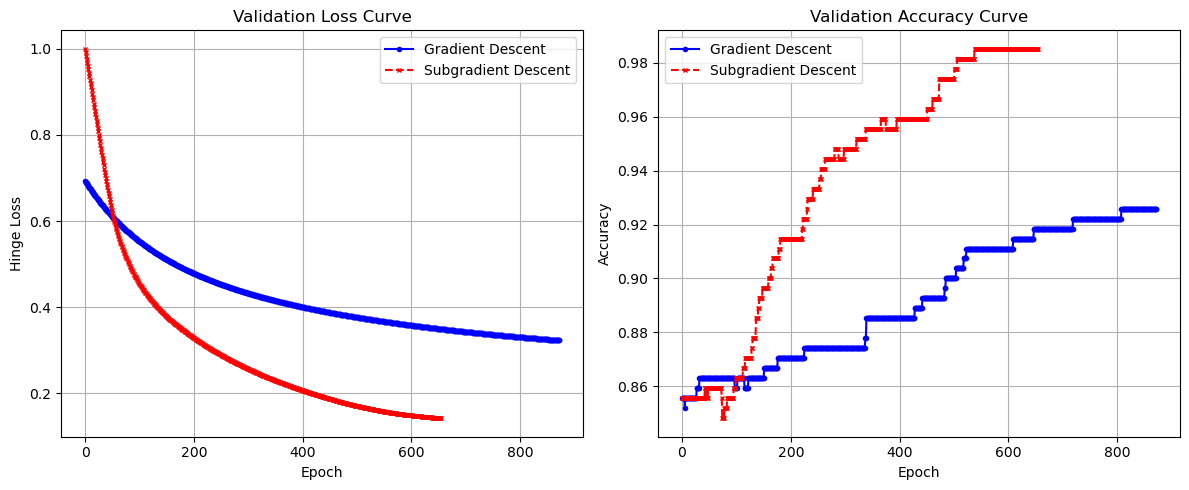

In [25]:
# Plot Loss Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(
    val_loss_grad,
    label="Gradient Descent",
    linestyle="-",
    color="blue",
    marker="o",
    markersize=3,
)
plt.plot(
    val_loss_sub,
    label="Subgradient Descent",
    linestyle="--",
    color="red",
    marker="x",
    markersize=3,
)
plt.title("Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Hinge Loss")
plt.legend()
plt.grid(True)

# Plot Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(
    val_acc_grad,
    label="Gradient Descent",
    linestyle="-",
    color="blue",
    marker="o",
    markersize=3,
)
plt.plot(
    val_acc_sub,
    label="Subgradient Descent",
    linestyle="--",
    color="red",
    marker="x",
    markersize=3,
)
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
(test_acc_grad-acc_grad[-1]),(test_acc_sub-acc_sub[-1])

(-0.017045298086190264, -0.00860525953462754)

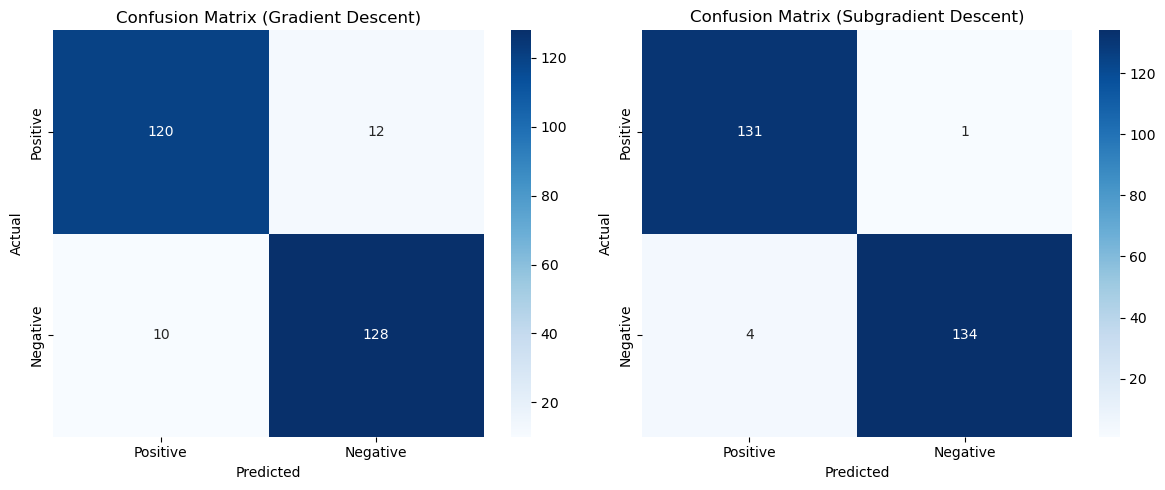

In [27]:
plt.figure(figsize=(12, 5))
plot_confusion(y_test, test_pred_grad, "Confusion Matrix (Gradient Descent)", 1, 2, 1)
plot_confusion(y_test, test_pred_sub, "Confusion Matrix (Subgradient Descent)", 1, 2, 2)
plt.tight_layout()
plt.show()

# Analysis

## **1) ✅ Accuracy & Final Losses:**

In [28]:
# Print comparison metrics
{
    "Gradient Descent Test Accuracy": float(round(test_acc_grad*100, 2)),
    "Subgradient Descent Test Accuracy": float(round(test_acc_sub*100, 2)),
    "Gradient Descent Final Loss": float(round(loss_grad[-1], 3)),
    "Subgradient Descent Final Loss": float(round(loss_sub[-1], 3))
}

{'Gradient Descent Test Accuracy': 91.85,
 'Subgradient Descent Test Accuracy': 98.15,
 'Gradient Descent Final Loss': 0.32,
 'Subgradient Descent Final Loss': 0.141}

# **_____________________________________________________________________________** 

## **2) ⚡ Convergence Speed:**
### The number of epochs each method takes indicates that the fewer epochs the higher convergence.
### **Result:** ```Sub-Gradient``` descent converges faster, likely due to smoother loss optimization.

In [29]:
len(val_loss_grad), len(val_loss_sub)

(873, 655)

# **_____________________________________________________________________________** 

## **3) 📉 Stability of the Loss Function:**
- After looking at the loss curve for both ```Gradiant``` and ```Sub-Gradiant``` we found out that:
    * 1) The ```Gradient``` loss curve has a smoother descent because of the differentiability of the logistic loss.
      2) The ```Sub-Gradiant``` loss curve have jumps or plateaus due to the piecewise nature of the hinge loss.

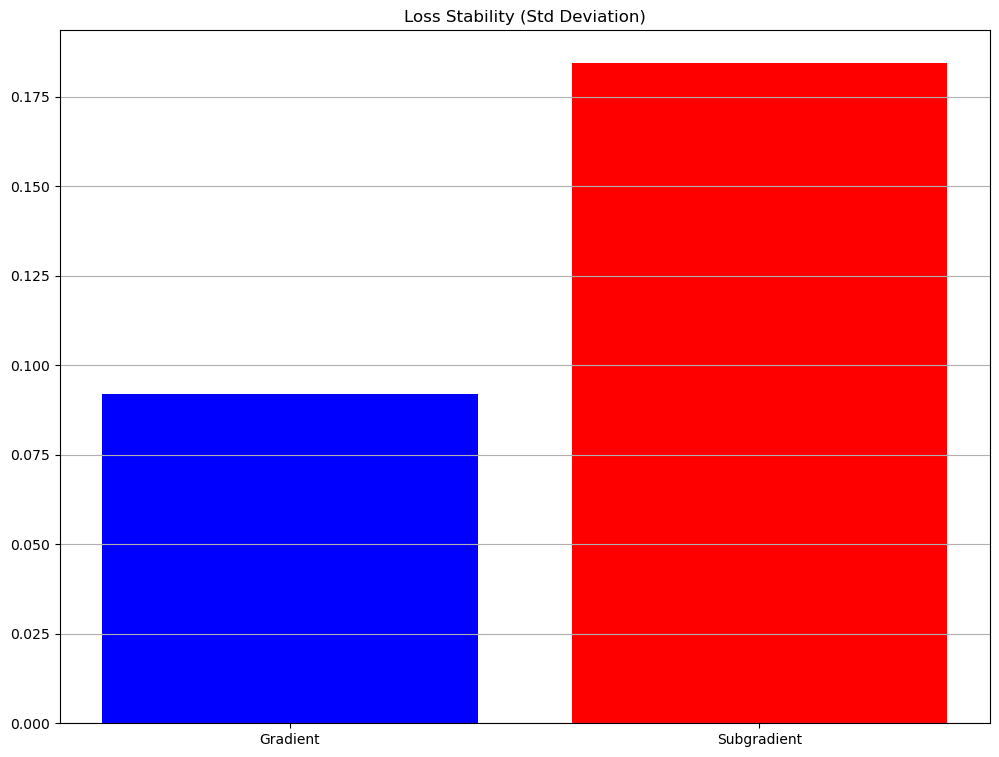

In [30]:
# 3. Stability (Loss Std Dev)
plt.figure(figsize=(12,9))
plt.bar(["Gradient", "Subgradient"],
              [np.std(loss_grad), np.std(loss_sub)],
              color=["blue", "red"])
plt.title("Loss Stability (Std Deviation)")
plt.grid(True, axis='y')
plt.show()

# **_____________________________________________________________________________** 

## **4) 🧠 Generalization on Test Data:**
- After evaluating both models on the test set using accuracy, precision, recall, and the confusion matrix:
    * 1) Both ```Gradient``` and ```Sub-Gradient``` methods achieved high precision and recall, indicating strong performance on unseen data.
      2) The ```Sub-Gradient``` method slightly outperformed in both precision (0.99) and recall (0.98), suggesting better handling of both false positives and false negatives.
      3) The consistency between validation and test performance shows that both models generalize well without signs of overfitting.

In [31]:
# Confusion matrices for both methods
cm_grad = confusion_matrix(y_test, test_pred_grad, labels=[1, -1])
cm_sub = confusion_matrix(y_test, test_pred_sub, labels=[1, -1])

# Extract values from the confusion matrix for Gradient Descent
TP_grad = cm_grad[0, 0]  # True Positive (Gradient Descent)
TN_grad = cm_grad[1, 1]  # True Negative (Gradient Descent)
FP_grad = cm_grad[0, 1]  # False Positive (Gradient Descent)
FN_grad = cm_grad[1, 0]  # False Negative (Gradient Descent)

# Extract values from the confusion matrix for Subgradient Descent
TP_sub = cm_sub[0, 0]  # True Positive (Subgradient Descent)
TN_sub = cm_sub[1, 1]  # True Negative (Subgradient Descent)
FP_sub = cm_sub[0, 1]  # False Positive (Subgradient Descent)
FN_sub = cm_sub[1, 0]  # False Negative (Subgradient Descent)

# Compute Precision and Recall for Gradient Descent
precision_grad = TP_grad / (TP_grad + FP_grad) if (TP_grad + FP_grad) != 0 else 0
recall_grad = TP_grad / (TP_grad + FN_grad) if (TP_grad + FN_grad) != 0 else 0

# Compute Precision and Recall for Subgradient Descent
precision_sub = TP_sub / (TP_sub + FP_sub) if (TP_sub + FP_sub) != 0 else 0
recall_sub = TP_sub / (TP_sub + FN_sub) if (TP_sub + FN_sub) != 0 else 0

# Print the results
print(f"Gradient Descent - Precision: {precision_grad:.2f}, Recall: {recall_grad:.2f}")
print(f"Subgradient Descent - Precision: {precision_sub:.2f}, Recall: {recall_sub:.2f}")


Gradient Descent - Precision: 0.91, Recall: 0.92
Subgradient Descent - Precision: 0.99, Recall: 0.97


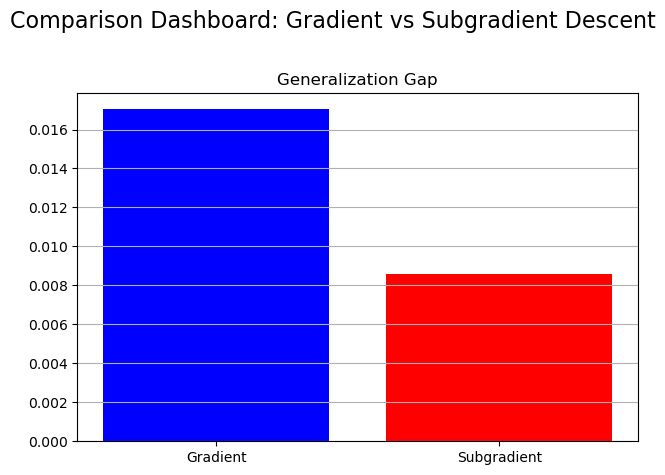

In [32]:
generalization_gap_grad = acc_grad[-1] - test_acc_grad
generalization_gap_sub = acc_sub[-1] - test_acc_sub

plt.bar(["Gradient", "Subgradient"],
              [generalization_gap_grad, generalization_gap_sub],
              color=["blue", "red"])
plt.title("Generalization Gap")
plt.grid(True, axis='y')

plt.suptitle("Comparison Dashboard: Gradient vs Subgradient Descent", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
